# 08 — Modelo Prophet: Series temporales nacionales

**Proyecto:** RepostaPro — Optimización del repostaje en flotas comerciales  
**Autor:** Víctor González Martín  
**Notebook:** 08 — Prophet sobre el precio medio nacional

## Objetivo del notebook

Entrenar y evaluar el modelo Prophet sobre la serie temporal del precio medio nacional de los dos carburantes del núcleo predictivo, separando los regímenes pre-shock y post-shock identificados en la Fase 1.

## Características de Prophet

Prophet descompone la serie temporal en componentes interpretables:

- **Tendencia**: dirección general (lineal o no lineal, con changepoints automáticos).
- **Estacionalidad anual**: efecto del mes y época del año.
- **Estacionalidad semanal**: efecto del día de la semana.
- **Intervalos de confianza nativos**: incertidumbre cuantificada de cada predicción.

## Modelos a entrenar

4 modelos en total:

| Modelo | Carburante | Régimen | Días entrenamiento |
|---|---|---|---|
| 1 | Gasóleo A | Pre-shock | ~636 días |
| 2 | Gasóleo A | Post-shock | ~61 días |
| 3 | Gasolina 95 E5 | Pre-shock | ~636 días |
| 4 | Gasolina 95 E5 | Post-shock | ~61 días |

El modelo post-shock dispone de menor histórico, lo que limitará la estimación de la estacionalidad anual. Se documentará como limitación.

In [1]:
# Configuración del entorno
import sys
import warnings
import logging
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Silenciar los logs internos de Prophet / Stan (muy ruidosos por defecto)
logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.family"] = "Calibri"
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")

# Añadir raíz del proyecto al sys.path
RAIZ_PROYECTO = Path("..").resolve()
if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROYECTO))

# Importar funciones de los módulos
from src.modelos import (cargar_todas_particiones,construir_serie_diaria,entrenar_prophet,predecir_prophet,evaluar_prophet_en_conjunto,imprimir_evaluacion,guardar_modelo_prophet,evaluar)

# Rutas
CARPETA_PARTICIONES = Path("../data/processed/particiones")
CARPETA_MODELOS = Path("../outputs/models/prophet")
CARPETA_RESULTADOS = Path("../outputs/resultados_modelos")
CARPETA_FIGURAS = Path("../outputs/figures")
CARPETA_MODELOS.mkdir(parents=True, exist_ok=True)
CARPETA_RESULTADOS.mkdir(parents=True, exist_ok=True)

print(f"Raíz del proyecto: {RAIZ_PROYECTO}")
print(f"Carpeta de modelos: {CARPETA_MODELOS.resolve()}")
print("\nMódulos importados correctamente")

Raíz del proyecto: C:\TFM
Carpeta de modelos: C:\TFM\outputs\models\prophet

Módulos importados correctamente


## Función auxiliar: pipeline completo Prophet

Encapsulamos en una función reutilizable todo el flujo: carga de particiones, construcción de serie diaria, entrenamiento, evaluación en train/val/test y guardado del modelo.

In [2]:
def pipeline_prophet(carburante, regimen):
    """Pipeline completo: carga datos, entrena Prophet, evalúa y guarda.

    Args:
        carburante: 'gasoleo_a' o 'gasolina_95'.
        regimen: 'pre_shock' o 'post_shock'.

    Returns:
        dict con modelo entrenado, métricas y serie de predicciones.
    """
    nombre_completo = f"{carburante.upper()} · {regimen.replace('_', ' ')}"
    print(f"\n>>> Entrenando Prophet: {nombre_completo}")
    print("=" * 70)

    # 1. Cargar particiones (train, val, test)
    particiones = cargar_todas_particiones(CARPETA_PARTICIONES, carburante, regimen)
    
    # 2. Construir serie diaria nacional para entrenamiento
    serie_train = construir_serie_diaria(particiones["train"])
    print(f"Días en serie de entrenamiento: {len(serie_train)}")
    print(f"Rango: {serie_train['ds'].min().date()} → {serie_train['ds'].max().date()}")
    
# 3. Entrenar Prophet con estacionalidad MULTIPLICATIVA y tendencia flexible
    parametros = {
        "yearly_seasonality": True if regimen == "pre_shock" else False,
        "weekly_seasonality": True,
        "daily_seasonality": False,
        "interval_width": 0.80,
        "changepoint_prior_scale": 0.5,
        "changepoint_range": 1.0,
        "seasonality_prior_scale": 5.0,
        "seasonality_mode": "multiplicative"}
    
    modelo = entrenar_prophet(serie_train, **parametros)
    print(f"✓ Modelo entrenado (cps=0.5, seasonality_mode=multiplicative)")
    
    # 4. Evaluar en los 3 conjuntos
    resultados = []
    for conjunto in ["train", "val", "test"]:
        resultado = evaluar_prophet_en_conjunto(modelo, particiones[conjunto],nombre=f"Prophet · {nombre_completo} · {conjunto}")
        resultados.append(resultado)
    
    imprimir_evaluacion(resultados)
    
    # 5. Guardar modelo
    ruta_modelo = CARPETA_MODELOS / f"prophet_{carburante}_{regimen}.json"
    guardar_modelo_prophet(modelo, ruta_modelo)
    print(f"\n✓ Modelo guardado en: {ruta_modelo.name}")
    
    return {
        "carburante": carburante,
        "regimen": regimen,
        "modelo": modelo,
        "resultados": resultados,
        "particiones": particiones}

print("Función pipeline_prophet definida")

Función pipeline_prophet definida


## Entrenamiento: Gasóleo A · Pre-shock

Primer modelo. Esta combinación tiene la serie más larga (636 días de entrenamiento), por lo que debería ser la más robusta.

In [3]:
resultado_gasoleo_pre = pipeline_prophet("gasoleo_a", "pre_shock")


>>> Entrenando Prophet: GASOLEO_A · pre shock
Días en serie de entrenamiento: 636
Rango: 2024-01-01 → 2025-09-30


C:\Users\vicgon\AppData\Local\anaconda3\envs\repostapro\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
23:56:59 - cmdstanpy - INFO - Chain [1] start processing
23:56:59 - cmdstanpy - INFO - Chain [1] done processing


✓ Modelo entrenado (cps=0.5, seasonality_mode=multiplicative)
Conjunto                                   N obs    MAE (cts)   RMSE (cts)     MAPE (%)
------------------------------------------------------------------------------------------
Prophet · GASOLEO_A · pre shock · train          636       0.277        0.368        0.191
Prophet · GASOLEO_A · pre shock · val           92       5.448        6.017        3.863
Prophet · GASOLEO_A · pre shock · test           59       8.690        8.744        6.197

✓ Modelo guardado en: prophet_gasoleo_a_pre_shock.json


## Entrenamiento: Gasóleo A · Post-shock

Modelo con menos datos (61 días de train). Estacionalidad anual desactivada por insuficiencia de muestra.

In [4]:
resultado_gasoleo_post = pipeline_prophet("gasoleo_a", "post_shock")


>>> Entrenando Prophet: GASOLEO_A · post shock
Días en serie de entrenamiento: 61
Rango: 2026-03-01 → 2026-04-30


23:57:01 - cmdstanpy - INFO - Chain [1] start processing
23:57:01 - cmdstanpy - INFO - Chain [1] done processing


✓ Modelo entrenado (cps=0.5, seasonality_mode=multiplicative)
Conjunto                                   N obs    MAE (cts)   RMSE (cts)     MAPE (%)
------------------------------------------------------------------------------------------
Prophet · GASOLEO_A · post shock · train           61       0.558        0.951        0.311
Prophet · GASOLEO_A · post shock · val           24       5.283        6.238        3.120
Prophet · GASOLEO_A · post shock · test           21      17.317       17.704       10.676

✓ Modelo guardado en: prophet_gasoleo_a_post_shock.json


## Entrenamiento: Gasolina 95 E5 · Pre-shock y Post-shock

In [5]:
resultado_gasolina_pre = pipeline_prophet("gasolina_95", "pre_shock")
resultado_gasolina_post = pipeline_prophet("gasolina_95", "post_shock")


>>> Entrenando Prophet: GASOLINA_95 · pre shock
Días en serie de entrenamiento: 636
Rango: 2024-01-01 → 2025-09-30


23:57:05 - cmdstanpy - INFO - Chain [1] start processing
23:57:06 - cmdstanpy - INFO - Chain [1] done processing


✓ Modelo entrenado (cps=0.5, seasonality_mode=multiplicative)
Conjunto                                   N obs    MAE (cts)   RMSE (cts)     MAPE (%)
------------------------------------------------------------------------------------------
Prophet · GASOLINA_95 · pre shock · train          636       0.240        0.308        0.156
Prophet · GASOLINA_95 · pre shock · val           92       3.072        3.948        2.100
Prophet · GASOLINA_95 · pre shock · test           59       1.429        1.634        0.984

✓ Modelo guardado en: prophet_gasolina_95_pre_shock.json

>>> Entrenando Prophet: GASOLINA_95 · post shock


23:57:07 - cmdstanpy - INFO - Chain [1] start processing


Días en serie de entrenamiento: 61
Rango: 2026-03-01 → 2026-04-30


23:57:07 - cmdstanpy - INFO - Chain [1] done processing


✓ Modelo entrenado (cps=0.5, seasonality_mode=multiplicative)
Conjunto                                   N obs    MAE (cts)   RMSE (cts)     MAPE (%)
------------------------------------------------------------------------------------------
Prophet · GASOLINA_95 · post shock · train           61       0.540        1.031        0.335
Prophet · GASOLINA_95 · post shock · val           24       2.680        3.127        1.720
Prophet · GASOLINA_95 · post shock · test           21      13.507       14.222        8.862

✓ Modelo guardado en: prophet_gasolina_95_post_shock.json


## Visualización de los componentes Prophet

Prophet permite descomponer visualmente la tendencia y la estacionalidad. Generamos la figura para el modelo pre-shock de Gasóleo A (el más rico en datos), que será una pieza clave de la memoria.

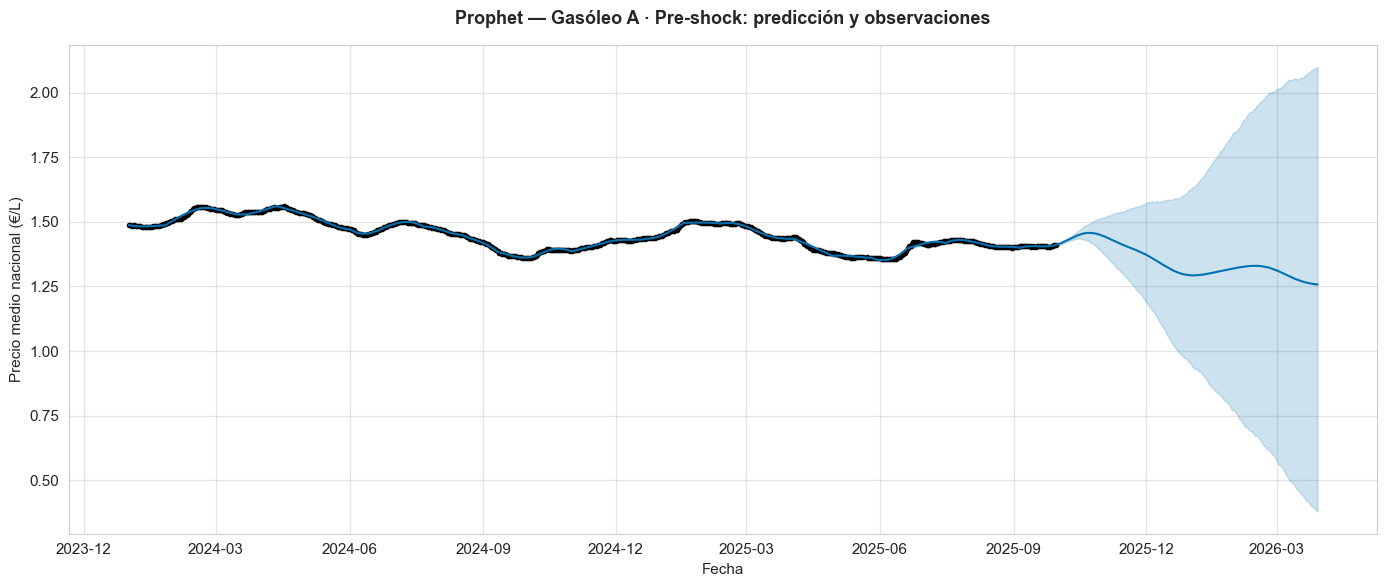

Figura guardada: prophet_gasoleo_pre_prediccion.png


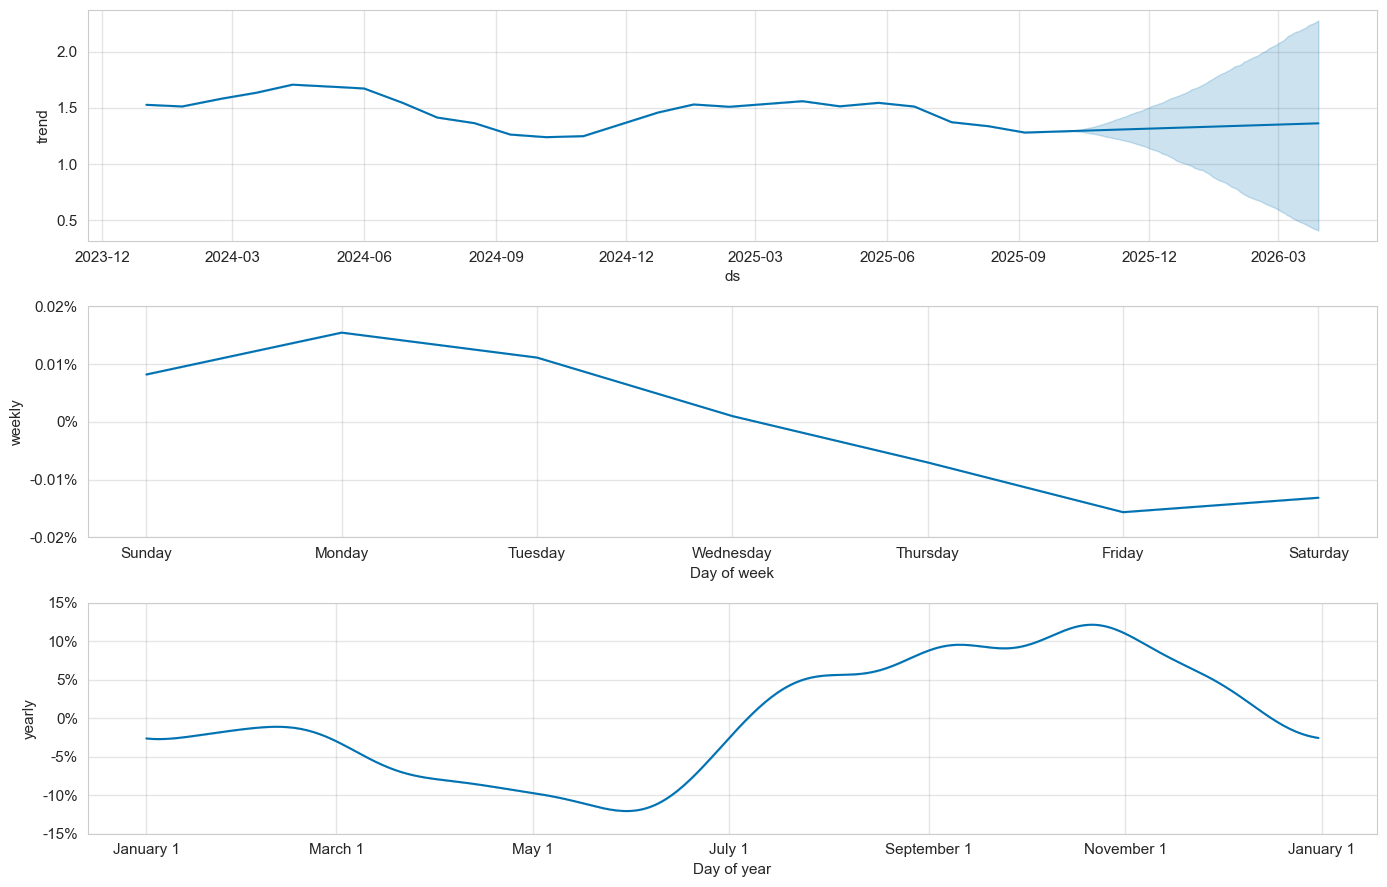

Figura guardada: prophet_gasoleo_pre_componentes.png


In [6]:
# Componentes del modelo Gasóleo A pre-shock
modelo = resultado_gasoleo_pre["modelo"]
serie_train = construir_serie_diaria(resultado_gasoleo_pre["particiones"]["train"])

# Generar predicción para visualización
df_futuro = modelo.make_future_dataframe(periods=180)
prediccion = modelo.predict(df_futuro)

# Figura 1: predicción global
fig1 = modelo.plot(prediccion, figsize=(14, 6))
plt.title("Prophet — Gasóleo A · Pre-shock: predicción y observaciones",fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Fecha")
plt.ylabel("Precio medio nacional (€/L)")
plt.tight_layout()
ruta_fig1 = CARPETA_FIGURAS / "prophet_gasoleo_pre_prediccion.png"
plt.savefig(ruta_fig1, dpi=200, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {ruta_fig1.name}")

# Figura 2: componentes (tendencia + estacionalidades)
fig2 = modelo.plot_components(prediccion, figsize=(14, 9))
plt.tight_layout()
ruta_fig2 = CARPETA_FIGURAS / "prophet_gasoleo_pre_componentes.png"
plt.savefig(ruta_fig2, dpi=200, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {ruta_fig2.name}")

In [7]:
# Consolidar resultados de los 4 modelos
todos_resultados = (resultado_gasoleo_pre["resultados"] +resultado_gasoleo_post["resultados"] +
    resultado_gasolina_pre["resultados"] +resultado_gasolina_post["resultados"])

df_resultados = pd.DataFrame(todos_resultados)
df_resultados["modelo"] = "prophet"
df_resultados = df_resultados[["modelo", "nombre", "n_observaciones", "mae_cts", "rmse_cts", "mape_pct"]]

ruta_resultados = CARPETA_RESULTADOS / "prophet_resultados.csv"
df_resultados.to_csv(ruta_resultados, index=False)

print(f"=" * 70)
print(f"RESUMEN GLOBAL PROPHET")
print(f"=" * 70)
print(df_resultados.to_string(index=False))

print(f"\n✓ Resultados guardados en: {ruta_resultados}")

# Resumen ejecutivo: comparativa con baseline en TEST
print(f"\n{'─' * 70}")
print(f"COMPARATIVA RÁPIDA CON BASELINE EN TEST")
print(f"{'─' * 70}")

baseline_test = pd.read_csv(CARPETA_RESULTADOS / "baseline_resultados.csv")
baseline_test = baseline_test[baseline_test["nombre"].str.contains("test")][["nombre", "mae_cts"]].rename(columns={"mae_cts": "baseline_mae"})

prophet_test = df_resultados[df_resultados["nombre"].str.contains("test")][["nombre", "mae_cts"]].rename(columns={"mae_cts": "prophet_mae"})

# Limpiar prefijo "Prophet · " del nombre para hacer match
prophet_test["nombre"] = prophet_test["nombre"].str.replace("Prophet · ", "", regex=False)
baseline_test["nombre"] = (baseline_test["nombre"].str.replace(" · ", " · ", regex=False))
comparativa = baseline_test.merge(prophet_test, on="nombre", how="outer")
comparativa["mejora_cts"] = comparativa["baseline_mae"] - comparativa["prophet_mae"]
comparativa["mejora_%"] = (comparativa["mejora_cts"] / comparativa["baseline_mae"] * 100).round(1)

print(comparativa.to_string(index=False))

RESUMEN GLOBAL PROPHET
 modelo                                     nombre  n_observaciones   mae_cts  rmse_cts  mape_pct
prophet    Prophet · GASOLEO_A · pre shock · train              636  0.276504  0.367589  0.191392
prophet      Prophet · GASOLEO_A · pre shock · val               92  5.448233  6.017395  3.863213
prophet     Prophet · GASOLEO_A · pre shock · test               59  8.689699  8.744178  6.196931
prophet   Prophet · GASOLEO_A · post shock · train               61  0.558043  0.950800  0.311417
prophet     Prophet · GASOLEO_A · post shock · val               24  5.283005  6.237998  3.119969
prophet    Prophet · GASOLEO_A · post shock · test               21 17.316507 17.704496 10.675992
prophet  Prophet · GASOLINA_95 · pre shock · train              636  0.239917  0.308474  0.156410
prophet    Prophet · GASOLINA_95 · pre shock · val               92  3.071741  3.948495  2.100217
prophet   Prophet · GASOLINA_95 · pre shock · test               59  1.428891  1.633550  0.9841

## Ajuste metodológico: baseline nacional para comparación justa

El baseline original se calcula a nivel de **estación individual** (~650.000 predicciones por test). Prophet, en cambio, predice a nivel **nacional agregado** (~59 predicciones por test). Esta diferencia hace que el baseline sea artificialmente bueno por la inercia día a día de cada estación.

Para una comparativa metodológicamente honesta, calculamos también el baseline aplicado a la **serie nacional agregada** (media móvil 7 días del precio medio nacional diario). Esta es la cifra que debería compararse con Prophet.

In [10]:
# Calcular el baseline nacional (MM7 de la serie nacional agregada)
print(f"{'=' * 70}")
print(f"BASELINE NACIONAL — comparación justa con Prophet")
print(f"{'=' * 70}")

baseline_nacional_resultados = []

for carburante in ["gasoleo_a", "gasolina_95"]:
    for regimen in ["pre_shock", "post_shock"]:
        # Cargar las 3 particiones
        particiones = cargar_todas_particiones(CARPETA_PARTICIONES, carburante, regimen)
        
        # Construir serie nacional COMPLETA (train + val + test concatenados en orden)
        serie_train = construir_serie_diaria(particiones["train"])
        serie_val   = construir_serie_diaria(particiones["val"])
        serie_test  = construir_serie_diaria(particiones["test"])
        
        # Combinar en orden temporal
        serie_completa = pd.concat([serie_train, serie_val, serie_test]).sort_values("ds").reset_index(drop=True)
        
        # Calcular MM7 sobre la serie nacional
        serie_completa["mm7"] = serie_completa["y"].shift(1).rolling(window=7, min_periods=1).mean()
        
        # Evaluar baseline nacional en cada conjunto
        for nombre_conjunto, serie_conjunto in [
            ("train", serie_train), ("val", serie_val), ("test", serie_test)]:
            sub = serie_completa[serie_completa["ds"].isin(serie_conjunto["ds"])].copy()
            resultado = evaluar(sub["y"].values, sub["mm7"].values,
                nombre=f"Baseline-NACIONAL · {carburante.upper()} · {regimen.replace('_', ' ')} · {nombre_conjunto}")
            baseline_nacional_resultados.append(resultado)

imprimir_evaluacion(baseline_nacional_resultados)

# Guardar
df_baseline_nacional = pd.DataFrame(baseline_nacional_resultados)
df_baseline_nacional["modelo"] = "baseline_nacional_mm7"
df_baseline_nacional = df_baseline_nacional[["modelo", "nombre", "n_observaciones", "mae_cts", "rmse_cts", "mape_pct"]]
ruta_baseline_nacional = CARPETA_RESULTADOS / "baseline_nacional_resultados.csv"
df_baseline_nacional.to_csv(ruta_baseline_nacional, index=False)
print(f"\nGuardado en: {ruta_baseline_nacional}")

BASELINE NACIONAL — comparación justa con Prophet
Conjunto                                   N obs    MAE (cts)   RMSE (cts)     MAPE (%)
------------------------------------------------------------------------------------------
Baseline-NACIONAL · GASOLEO_A · pre shock · train          635       0.559        0.726        0.385
Baseline-NACIONAL · GASOLEO_A · pre shock · val           92       0.672        0.745        0.475
Baseline-NACIONAL · GASOLEO_A · pre shock · test           59       0.369        0.451        0.262
Baseline-NACIONAL · GASOLEO_A · post shock · train           60       5.700        7.149        3.221
Baseline-NACIONAL · GASOLEO_A · post shock · val           24       1.117        1.498        0.656
Baseline-NACIONAL · GASOLEO_A · post shock · test           21       1.744        1.843        1.069
Baseline-NACIONAL · GASOLINA_95 · pre shock · train          635       0.462        0.617        0.299
Baseline-NACIONAL · GASOLINA_95 · pre shock · val           92   